# 05 - PCA vs. Features Originales

**Proyecto:** Pochoclo Predict

## Objetivo de este notebook

En `03_feature_engineering.ipynb` (seccion 15) se encontro que hacen falta
**80 de las 105 features** (tras estandarizar) para explicar el 90% de la
varianza del dataset. Esto plantea la pregunta: ¿entrenar los mismos modelos
de `04_modelos_predictivos.ipynb` sobre esas 80 componentes principales
-en lugar de las 105 features originales- cambia el desempeño?

Este notebook:

1. Reentrena los **mismos 7 modelos** (mismos hiperparametros candidatos,
   misma metodologia de busqueda) de NB04, una vez sobre las features
   originales y otra vez sobre 80 componentes de PCA.
2. Compara ambos resultados modelo por modelo.
3. Aplica un **test de Wilcoxon** (test no parametrico para muestras
   apareadas) sobre el MAE de cada modelo bajo ambas representaciones, para
   determinar si la diferencia observada es estadisticamente significativa
   o podria deberse al azar.

Es un notebook de **evaluacion/ablacion**: no reemplaza ni modifica el
modelo final guardado en `04_modelos_predictivos.ipynb`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from src import paths

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
N_COMPONENTES_PCA = 80  # hallado en NB03: explica ~90% de la varianza

# Este notebook entrena los 7 modelos DOS veces (features originales y PCA),
# el doble de trabajo que NB04. Para que la corrida completa siga siendo
# practica, se usa una busqueda de hiperparametros mas liviana que en NB04
# (menos combinaciones probadas, menos folds de CV). El objetivo aca es
# comparar de forma justa las dos representaciones, no volver a encontrar el
# mejor hiperparametro posible en terminos absolutos -eso ya se hizo en NB04-.
N_ITER_BUSQUEDA = 8
CV_FOLDS = 3


## 1. Carga de datos y particion train/test

Mismo `random_state` que NB04 para que la particion train/test sea
identica y la comparacion entre representaciones (original vs. PCA) sea
justa.


In [2]:
feat = pd.read_csv(paths.FEATURES_CSV, encoding="utf-8-sig")

X = feat.drop(columns=["id", "nota_promedio"]).astype("float64")
y = feat["nota_promedio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} peliculas | Test: {X_test.shape[0]} peliculas | Features originales: {X_train.shape[1]}")


Train: 3287 peliculas | Test: 822 peliculas | Features originales: 105


## 2. Reduccion a componentes principales

El `StandardScaler` y el `PCA` se **ajustan solo sobre el train** y se
aplican (transform) sobre el test: ajustarlos sobre el dataset completo
filtraria informacion del test set hacia el entrenamiento (data leakage),
aunque sea "solo" para una transformacion no supervisada.

Como el ajuste es unicamente sobre el train (distinto del PCA exploratorio
de NB03, que se hizo sobre el dataset completo), la varianza explicada real
por estas 80 componentes puede diferir levemente del 90% encontrado en NB03.


In [3]:
scaler_pca = StandardScaler().fit(X_train)
X_train_std = scaler_pca.transform(X_train)
X_test_std = scaler_pca.transform(X_test)

pca = PCA(n_components=N_COMPONENTES_PCA, random_state=RANDOM_STATE)
X_train_pca = pd.DataFrame(pca.fit_transform(X_train_std), index=X_train.index)
X_test_pca = pd.DataFrame(pca.transform(X_test_std), index=X_test.index)

print(f"Varianza explicada por las {N_COMPONENTES_PCA} componentes (ajustadas solo en train): {pca.explained_variance_ratio_.sum():.1%}")


Varianza explicada por las 80 componentes (ajustadas solo en train): 90.6%


## 3. Modelos y busqueda de hiperparametros

Mismos modelos y mismos espacios de busqueda que `04_modelos_predictivos.ipynb`,
para que la unica diferencia entre una corrida y otra sea la representacion
de los datos (features originales vs. componentes de PCA).


In [4]:
def construir_param_distributions():
    return {
        "Ridge": {
            "estimator": Pipeline([("scaler", StandardScaler()), ("modelo", Ridge(random_state=RANDOM_STATE))]),
            "params": {"modelo__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 300.0]},
        },
        "ElasticNet": {
            "estimator": Pipeline([("scaler", StandardScaler()), ("modelo", ElasticNet(random_state=RANDOM_STATE, max_iter=20000))]),
            "params": {
                "modelo__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
                "modelo__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
            },
        },
        "Gradient Boosting": {
            "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
            "params": {
                "n_estimators": [100, 200, 300],
                "max_depth": [2, 3, 4],
                "learning_rate": [0.01, 0.05, 0.1],
                "subsample": [0.7, 0.9, 1.0],
            },
        },
        "HistGradientBoosting": {
            "estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            "params": {
                "max_iter": [100, 200, 300],
                "max_depth": [None, 3, 5, 8],
                "learning_rate": [0.01, 0.05, 0.1],
                "l2_regularization": [0.0, 0.1, 1.0],
            },
        },
        "XGBoost": {
            "estimator": XGBRegressor(random_state=RANDOM_STATE, objective="reg:squarederror"),
            "params": {
                "n_estimators": [200, 400, 600],
                "max_depth": [3, 4, 5, 6],
                "learning_rate": [0.01, 0.03, 0.05, 0.1],
                "subsample": [0.7, 0.9, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0],
            },
        },
        "LightGBM": {
            "estimator": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
            "params": {
                "n_estimators": [200, 400, 600],
                "num_leaves": [15, 31, 63],
                "learning_rate": [0.01, 0.03, 0.05, 0.1],
                "subsample": [0.7, 0.9, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0],
            },
        },
        "CatBoost": {
            "estimator": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, allow_writing_files=False),
            "params": {
                "iterations": [200, 400, 600],
                "depth": [4, 6, 8],
                "learning_rate": [0.01, 0.03, 0.05, 0.1],
                "l2_leaf_reg": [1, 3, 5, 7],
            },
        },
    }


def evaluar(nombre, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "MAPE": mean_absolute_percentage_error(y_test, pred),
    }


def entrenar_y_evaluar_todos(X_tr, X_te, y_tr, y_te, etiqueta):
    resultados = []
    baseline = DummyRegressor(strategy="mean")
    baseline.fit(X_tr, y_tr)
    resultados.append(evaluar("Baseline (media)", baseline, X_te, y_te))

    for nombre, cfg in construir_param_distributions().items():
        print(f"[{etiqueta}] Buscando hiperparametros para {nombre}...")
        busqueda = RandomizedSearchCV(
            estimator=cfg["estimator"],
            param_distributions=cfg["params"],
            n_iter=N_ITER_BUSQUEDA,
            cv=CV_FOLDS,
            scoring="neg_mean_absolute_error",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        busqueda.fit(X_tr, y_tr)
        resultados.append(evaluar(nombre, busqueda.best_estimator_, X_te, y_te))

    return pd.DataFrame(resultados)


## 4. Entrenamiento sobre las features originales (105)


In [5]:
resultados_original = entrenar_y_evaluar_todos(X_train, X_test, y_train, y_test, etiqueta="original")
resultados_original.sort_values("MAE").reset_index(drop=True)


[original] Buscando hiperparametros para Ridge...


C:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\webmining\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 7 is smaller than n_iter=8. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[original] Buscando hiperparametros para ElasticNet...


[original] Buscando hiperparametros para Gradient Boosting...


[original] Buscando hiperparametros para HistGradientBoosting...


[original] Buscando hiperparametros para XGBoost...


[original] Buscando hiperparametros para LightGBM...


[original] Buscando hiperparametros para CatBoost...


,modelo,MAE,RMSE,R2,MAPE
0,CatBoost,0.602875,0.765069,0.310709,0.105019
1,LightGBM,0.604662,0.770381,0.301104,0.105403
2,HistGradientBoosting,0.604835,0.770061,0.301684,0.105227
3,XGBoost,0.607433,0.770449,0.300980,0.105895
4,Gradient Boosting,0.616563,0.782870,0.278259,0.107521
5,Ridge,0.633123,0.802707,0.241220,0.110379
6,ElasticNet,0.633199,0.801959,0.242634,0.110323
7,Baseline (media),0.731727,0.921555,-0.000101,0.128341


## 5. Entrenamiento sobre las 80 componentes de PCA


In [6]:
resultados_pca = entrenar_y_evaluar_todos(X_train_pca, X_test_pca, y_train, y_test, etiqueta="PCA")
resultados_pca.sort_values("MAE").reset_index(drop=True)


[PCA] Buscando hiperparametros para Ridge...


C:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\webmining\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 7 is smaller than n_iter=8. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[PCA] Buscando hiperparametros para ElasticNet...


[PCA] Buscando hiperparametros para Gradient Boosting...


[PCA] Buscando hiperparametros para HistGradientBoosting...


[PCA] Buscando hiperparametros para XGBoost...


[PCA] Buscando hiperparametros para LightGBM...


[PCA] Buscando hiperparametros para CatBoost...


,modelo,MAE,RMSE,R2,MAPE
0,CatBoost,0.641502,0.813071,0.221501,0.111761
1,XGBoost,0.647479,0.821259,0.205741,0.112553
2,HistGradientBoosting,0.648681,0.819709,0.208737,0.113113
3,LightGBM,0.649674,0.820811,0.206608,0.113280
4,Ridge,0.650732,0.825588,0.197346,0.113580
5,Gradient Boosting,0.652534,0.820240,0.207712,0.113533
6,ElasticNet,0.652699,0.825780,0.196972,0.113836
7,Baseline (media),0.731727,0.921555,-0.000101,0.128341


## 6. Comparacion


In [7]:
comparacion = resultados_original.merge(
    resultados_pca, on="modelo", suffixes=("_original", "_pca")
)
comparacion["diferencia_MAE"] = comparacion["MAE_pca"] - comparacion["MAE_original"]
comparacion["mejora_PCA_%"] = -100 * comparacion["diferencia_MAE"] / comparacion["MAE_original"]
comparacion = comparacion.sort_values("MAE_original")[
    ["modelo", "MAE_original", "MAE_pca", "diferencia_MAE", "mejora_PCA_%", "R2_original", "R2_pca"]
].reset_index(drop=True)
comparacion


,modelo,MAE_original,MAE_pca,diferencia_MAE,mejora_PCA_%,R2_original,R2_pca
0,CatBoost,0.602875,0.641502,0.038626,-6.407034,0.310709,0.221501
1,LightGBM,0.604662,0.649674,0.045012,-7.444167,0.301104,0.206608
2,HistGradientBoosting,0.604835,0.648681,0.043845,-7.249114,0.301684,0.208737
3,XGBoost,0.607433,0.647479,0.040046,-6.592681,0.300980,0.205741
4,Gradient Boosting,0.616563,0.652534,0.035971,-5.834172,0.278259,0.207712
5,Ridge,0.633123,0.650732,0.017609,-2.781226,0.241220,0.197346
6,ElasticNet,0.633199,0.652699,0.019500,-3.079525,0.242634,0.196972
7,Baseline (media),0.731727,0.731727,0.000000,-0.000000,-0.000101,-0.000101


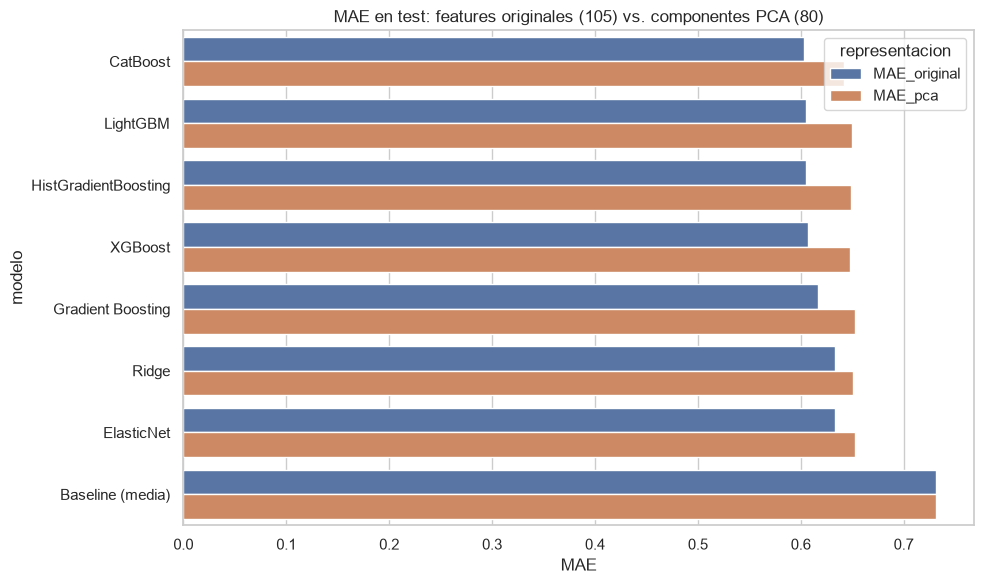

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
comparacion_larga = comparacion.melt(id_vars="modelo", value_vars=["MAE_original", "MAE_pca"],
                                      var_name="representacion", value_name="MAE")
sns.barplot(data=comparacion_larga, x="MAE", y="modelo", hue="representacion", ax=ax, orient="h")
ax.set_title("MAE en test: features originales (105) vs. componentes PCA (80)")
plt.tight_layout()
plt.show()


## 7. Test de Wilcoxon

El **baseline** (`DummyRegressor`) se excluye de este test: al ignorar por
completo las features, su MAE es identico bajo ambas representaciones (una
diferencia de cero garantizada que no aporta informacion a la comparacion).

Se comparan los 7 modelos restantes de forma **apareada** (mismo modelo,
features originales vs. PCA) con un test de **Wilcoxon de rangos con signo**
-la alternativa no parametrica al t-test apareado, apropiada aca porque son
solo 7 observaciones y no hay forma de asumir que las diferencias de MAE se
distribuyen normalmente-. Esta es tambien la metodologia que recomienda la
literatura de ML para comparar dos tratamientos (en este caso, dos
representaciones de features) a traves de multiples modelos (Demsar, 2006).

**Limitacion:** con solo 7 pares, el test tiene poca potencia estadistica -
puede no detectar una diferencia real aunque exista. El resultado hay que
leerlo con esa salvedad.


In [9]:
pares = comparacion[comparacion["modelo"] != "Baseline (media)"]

estadistico, p_valor = wilcoxon(pares["MAE_original"], pares["MAE_pca"])

print(f"Modelos comparados: {len(pares)}")
print(f"Estadistico de Wilcoxon: {estadistico:.3f}")
print(f"p-valor: {p_valor:.4f}")

alpha = 0.05
if p_valor < alpha:
    direccion = "mejora" if pares["diferencia_MAE"].mean() < 0 else "empeora"
    print(f"\nCon alpha={alpha}: la diferencia ES estadisticamente significativa (el PCA {direccion} el MAE en promedio).")
else:
    print(f"\nCon alpha={alpha}: la diferencia NO es estadisticamente significativa -no se puede descartar que sea azar-.")


Modelos comparados: 7
Estadistico de Wilcoxon: 0.000
p-valor: 0.0156

Con alpha=0.05: la diferencia ES estadisticamente significativa (el PCA empeora el MAE en promedio).


## 8. Conclusiones

- La tabla de la seccion 6 muestra, modelo por modelo, si reducir a 80
  componentes de PCA mejora, empeora o deja practicamente igual el MAE en
  test respecto de usar las 105 features originales.
- El test de Wilcoxon de la seccion 7 contextualiza esas diferencias: dice
  si son estadisticamente significativas o si, con esta cantidad de
  modelos comparados, son compatibles con variacion aleatoria.
- Mas alla del resultado numerico, usar las 105 features originales tiene
  una ventaja adicional que el PCA no ofrece: **interpretabilidad** (permite
  decir, como se hizo en el NB04 con SHAP, que feature especifica empuja la
  prediccion y en que direccion). Una mejora de PCA tendria que ser bastante
  grande y consistente para justificar perder esa interpretabilidad.
